In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
corpus = pd.read_csv("../data/output/CORPUS.csv", sep="|")
vocab_sent = pd.read_csv("../data/output/VOCAB_SENTIMENT_BY_BOOK.csv")
bow = pd.read_csv("../data/output/BOW.csv", sep="|")
lib = pd.read_csv("../data/output/LIB.csv", sep="|")

In [28]:
vocab = pd.read_csv("../data/output/VOCAB.csv", sep="|")

nrc_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "sadness", "surprise", "trust",
    "positive", "negative"
]

vocab_with_sent = pd.read_csv("../data/output/VOCAB.csv", sep="|")

# merge with NRC sentiment from notebook 18
nrc = pd.read_csv(
    "/Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/data/archive/NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
    sep="\t",
    header=None,
    names=["term_str", "emotion", "association"]
)

nrc = (
    nrc
    .pivot(index="term_str", columns="emotion", values="association")
    .fillna(0)
)

vocab_with_sent = (
    vocab
    .merge(nrc[nrc_cols],
           left_on="term_str",
           right_index=True,
           how="left")
)

vocab_with_sent[nrc_cols] = vocab_with_sent[nrc_cols].fillna(0)

In [29]:
bow.head()

,book_number,chapter,verse,term_str,n,idf,tfidf
0,1,1,1,and,1,0.264775,0.264775
1,1,1,1,beginning,1,5.700637,5.700637
2,1,1,1,created,1,6.707441,6.707441
3,1,1,1,earth,1,3.535988,3.535988
4,1,1,1,god,1,2.082210,2.082210


In [30]:
bow_sent = (
    bow
    .merge(
        vocab_with_sent[["term_str"] + nrc_cols],
        on="term_str",
        how="left"
    )
)

bow_sent[nrc_cols] = bow_sent[nrc_cols].fillna(0)

bow_sent.head()

,book_number,chapter,verse,term_str,n,idf,tfidf,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,1,1,1,and,1,0.264775,0.264775,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1,beginning,1,5.700637,5.700637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,created,1,6.707441,6.707441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,1,earth,1,3.535988,3.535988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,1,1,god,1,2.082210,2.082210,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0


In [31]:
for col in nrc_cols:
    bow_sent[col] = bow_sent[col] * bow_sent["n"]

In [32]:
verse_sentiment = (
    bow_sent
    .groupby(["book_number", "chapter", "verse"])[nrc_cols]
    .sum()
    .reset_index()
)

verse_sentiment.head()

,book_number,chapter,verse,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,1,1,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1,1,2,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,2.0,1.0
2,1,1,3,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
3,1,1,4,1.0,3.0,0.0,3.0,3.0,1.0,1.0,3.0,3.0,1.0
4,1,1,5,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0


In [33]:
verse_lengths = (
    bow
    .groupby(["book_number", "chapter", "verse"])["n"]
    .sum()
    .reset_index(name="token_count")
)

verse_sentiment = verse_sentiment.merge(
    verse_lengths,
    on=["book_number", "chapter", "verse"],
    how="left"
)

for col in nrc_cols:
    verse_sentiment[col] = verse_sentiment[col] / verse_sentiment["token_count"]

verse_sentiment.head()

,book_number,chapter,verse,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,token_count
0,1,1,1,0.000000,0.100000,0.0,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,0.000000,10
1,1,1,2,0.034483,0.034483,0.0,0.068966,0.034483,0.034483,0.000000,0.034483,0.068966,0.034483,29
2,1,1,3,0.000000,0.090909,0.0,0.090909,0.090909,0.000000,0.000000,0.090909,0.090909,0.000000,11
3,1,1,4,0.058824,0.176471,0.0,0.176471,0.176471,0.058824,0.058824,0.176471,0.176471,0.058824,17
4,1,1,5,0.045455,0.045455,0.0,0.090909,0.045455,0.045455,0.000000,0.045455,0.045455,0.045455,22


In [34]:
book_sent_bow = (
    verse_sentiment
    .groupby("book_number")[nrc_cols]
    .mean()
    .reset_index()
    .merge(
        lib[["book_number", "book_name", "testament"]],
        on="book_number",
        how="left"
    )
)

book_sent_bow.head()

,book_number,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,book_name,testament
0,1,0.008352,0.018713,0.010655,0.017280,0.022535,0.010256,0.006596,0.035766,0.047400,0.022831,Genesis,Old Testament
1,2,0.012557,0.016544,0.018988,0.017968,0.012993,0.010912,0.004941,0.036855,0.049103,0.033872,Exodus,Old Testament
2,3,0.016402,0.012896,0.044706,0.025085,0.015400,0.020123,0.006017,0.052104,0.060992,0.056391,Leviticus,Old Testament
3,4,0.011990,0.014214,0.025588,0.016544,0.011737,0.013618,0.005332,0.046609,0.049820,0.038396,Numbers,Old Testament
4,5,0.016568,0.028758,0.028863,0.032389,0.029398,0.014697,0.007938,0.057065,0.071778,0.048105,Deuteronomy,Old Testament


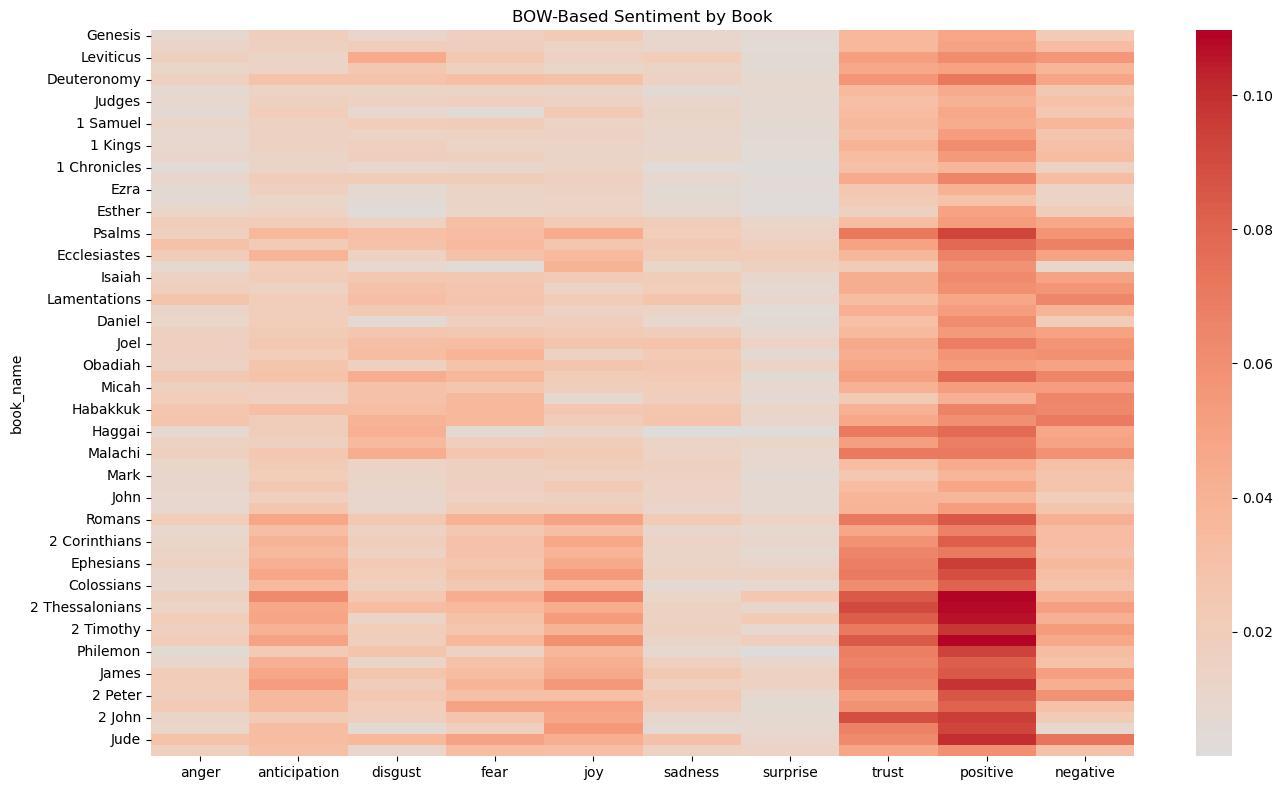

In [37]:
numeric_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "sadness", "surprise", "trust",
    "positive", "negative"
]

plt.figure(figsize=(14,8))

sns.heatmap(
    book_sent_bow.set_index("book_name")[numeric_cols],
    cmap="coolwarm",
    center=0
)

plt.title("BOW-Based Sentiment by Book")
plt.tight_layout()
plt.show()

In [38]:
output_path = "../data/output/BOW_SENT.csv"

bow_sent.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Saved:", output_path)

Saved: ../data/output/BOW_SENT.csv
